In [2]:
import pandas as pd
import glob
import os
import re

file_pattern = 'dbeq-basic-*.trades.csv' 
file_paths = glob.glob(file_pattern)

dataframes = {}

for file_path in file_paths:
    match = re.search(r'\d{8}', file_path)
    date_part = match.group(0) if match else 'unknown_date'
    file_key = f"NVDA-{date_part}"
    df = pd.read_csv(file_path)
    
    df_cleaned = df[['ts_event', 'price', 'size']].copy()
    df_cleaned['ts_event'] = pd.to_datetime(df_cleaned['ts_event']).dt.tz_localize(None)  

    trading_start = df_cleaned['ts_event'].dt.time >= pd.to_datetime("13:30:00").time()
    trading_end = df_cleaned['ts_event'].dt.time <= pd.to_datetime("19:59:59").time()
    df_filtered = df_cleaned[trading_start & trading_end]
    
    df_filtered.loc[:, 'ts_event'] = df_filtered['ts_event'].dt.strftime('%Y-%m-%d %H:%M:%S')

    dataframes[file_key] = df_filtered

# Display the head of each dataframe with the index reset for display purposes only
for key, df in dataframes.items():
    print(f"\nHead of {key}:")
    print(df.reset_index(drop=True).head(5))


Head of NVDA-20240828:
             ts_event   price  size
0 2024-08-28 13:30:00  128.12   200
1 2024-08-28 13:30:00  128.09    67
2 2024-08-28 13:30:00  128.09    33
3 2024-08-28 13:30:00  128.09    67
4 2024-08-28 13:30:00  128.09    33

Head of NVDA-20241004:
             ts_event   price  size
0 2024-10-04 13:30:00  124.93    43
1 2024-10-04 13:30:00  124.93    39
2 2024-10-04 13:30:00  124.93     5
3 2024-10-04 13:30:00  124.93    13
4 2024-10-04 13:30:00  124.92    11

Head of NVDA-20240730:
             ts_event    price  size
0 2024-07-30 13:30:00  111.515    90
1 2024-07-30 13:30:00  111.520    10
2 2024-07-30 13:30:00  111.520    18
3 2024-07-30 13:30:00  111.520   100
4 2024-07-30 13:30:00  111.520   100

Head of NVDA-20240613:
             ts_event    price  size
0 2024-06-13 13:30:00  129.390   100
1 2024-06-13 13:30:00  129.400   100
2 2024-06-13 13:30:00  129.400    74
3 2024-06-13 13:30:00  129.400    26
4 2024-06-13 13:30:00  129.445     4

Head of NVDA-20240624:
    

In [3]:
sorted_dataframes = dict(sorted(dataframes.items(), key=lambda x: x[0].split('-')[1]))
dataframes = sorted_dataframes

## 1. Volume model with no price simulated

In [4]:
volume_data = []

time_buckets = pd.date_range("13:30", "20:00", freq="15min").time

for key, df in dataframes.items():
    df['ts_event'] = pd.to_datetime(df['ts_event'])
    
    daily_volume = []

    for i in range(len(time_buckets) - 1):
        start_time = time_buckets[i]
        end_time = time_buckets[i + 1]
        
        volume_sum = df[(df['ts_event'].dt.time >= start_time) & (df['ts_event'].dt.time < end_time)]['size'].sum()

        daily_volume.append(volume_sum)
    
    volume_data.append(daily_volume)

volume_matrix = pd.DataFrame(volume_data)
volume_matrix


/var/folders/0_/58fmvk7j6w99vs8qqzxlk3hh0000gn/T/ipykernel_20098/3247708432.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ts_event'] = pd.to_datetime(df['ts_event'])


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,293250,258464,138803,154715,186693,139166,177720,109758,78626,167443,...,52416,45887,57200,78418,84908,72617,60265,126630,99444,558271
1,236268,173406,146117,121667,98420,105260,69783,59337,133552,141523,...,21310,18022,20876,17892,50961,21545,32203,55063,48988,93593
2,273187,149916,183355,105677,85284,90855,170617,248539,179456,534924,...,24576,17894,115863,33093,66885,419887,606276,155371,318481,188728
3,394004,134152,115109,145071,141278,65313,64835,110558,131717,41934,...,16298,29347,28772,23550,31235,58726,75105,63918,58020,174383
4,197130,120014,133727,93142,73897,86497,65975,85854,29260,69581,...,34298,29219,27730,29326,31105,50444,43895,3879668,43433,262610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,233507,158588,95536,87409,79129,51462,50441,56172,172547,97737,...,101041,1236807,41244,42464,93929,64070,46735,48972,196960,280269
98,323312,161226,95652,75849,55260,62755,109526,57482,45816,71238,...,48274,26373,28082,52684,54478,35484,92980,229502,73752,206846
99,348926,213303,183993,84448,321570,82489,65901,94485,120578,63683,...,66366,60948,49717,71659,787725,39806,77562,177217,90468,307755
100,256565,289624,210938,141961,126621,112719,94937,95816,74760,130946,...,84274,77324,79336,119134,71067,89762,109164,82227,102282,393022


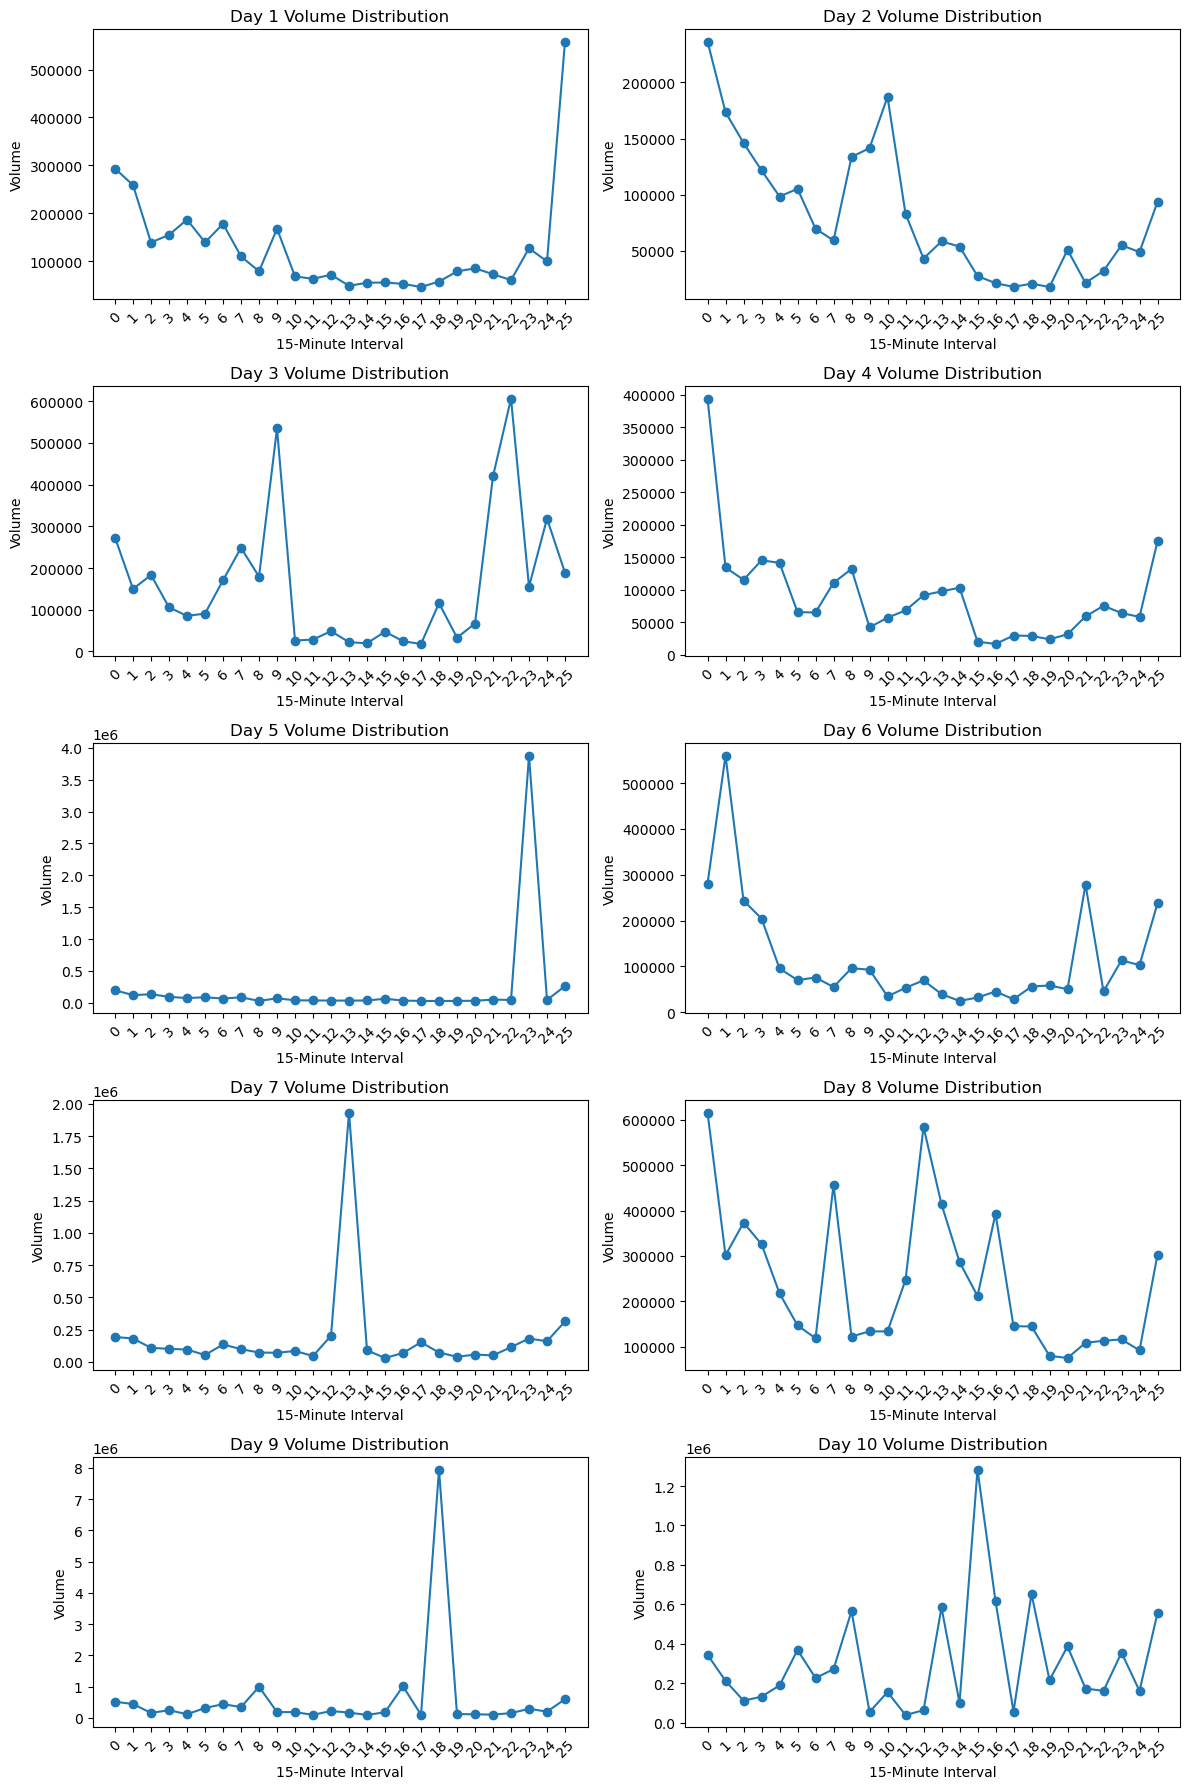

In [5]:
import matplotlib.pyplot as plt

volume_df = pd.DataFrame(volume_data[:10]).T 

fig, axs = plt.subplots(5, 2, figsize=(12, 18)) 

for i in range(10):
    row, col = divmod(i, 2) 
    axs[row, col].plot(volume_df.index, volume_df[i], marker='o')
    axs[row, col].set_title(f"Day {i+1} Volume Distribution")
    axs[row, col].set_xlabel("15-Minute Interval")
    axs[row, col].set_ylabel("Volume")
    axs[row, col].set_xticks(range(26)) 
    axs[row, col].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


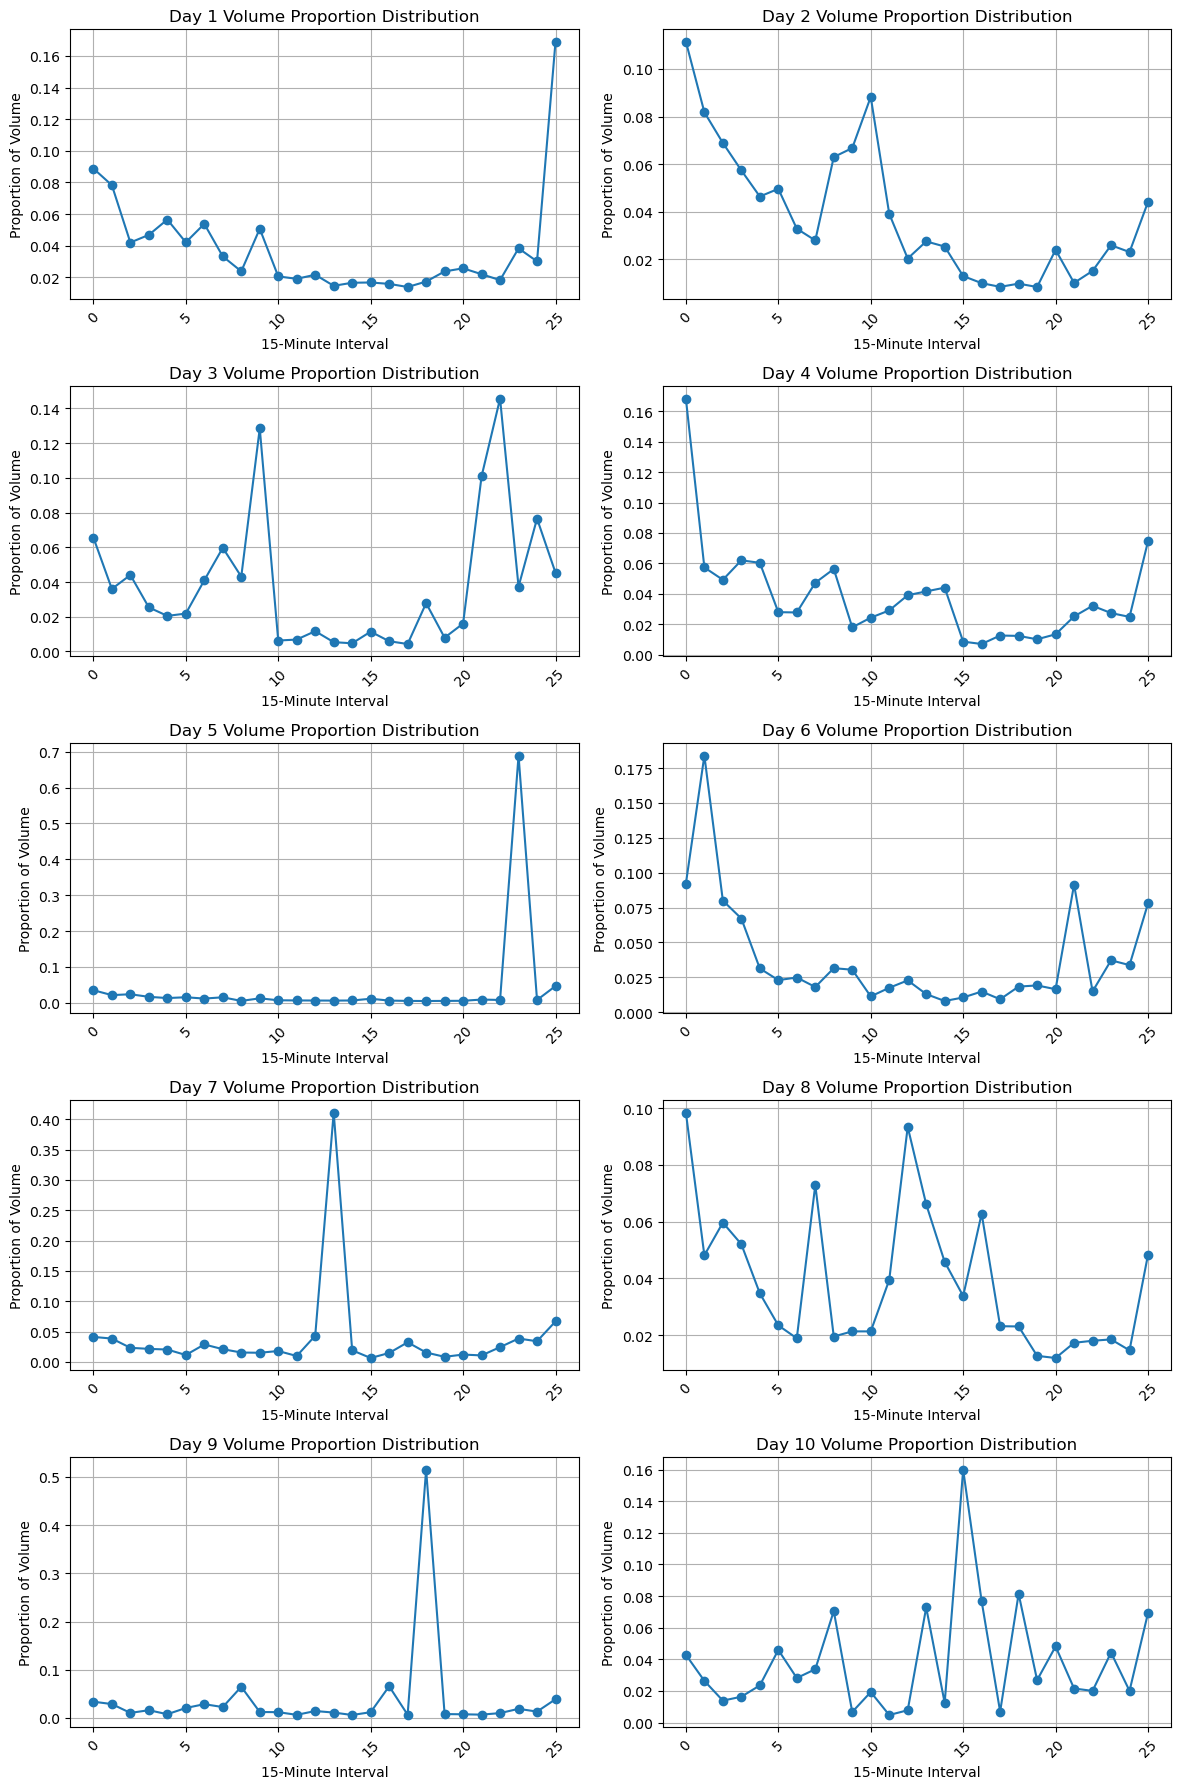

In [6]:
volume_proportion_matrix = volume_matrix.div(volume_matrix.sum(axis=1), axis=0)

fig, axs = plt.subplots(5, 2, figsize=(12, 18))

for i in range(10):
    row, col = divmod(i, 2) 
    axs[row, col].plot(volume_proportion_matrix.columns, volume_proportion_matrix.iloc[i], marker='o')
    axs[row, col].set_title(f"Day {i+1} Volume Proportion Distribution")
    axs[row, col].set_xlabel("15-Minute Interval")
    axs[row, col].set_ylabel("Proportion of Volume")
    axs[row, col].tick_params(axis='x', rotation=45) 
    axs[row, col].grid(True)

plt.tight_layout()
plt.show()



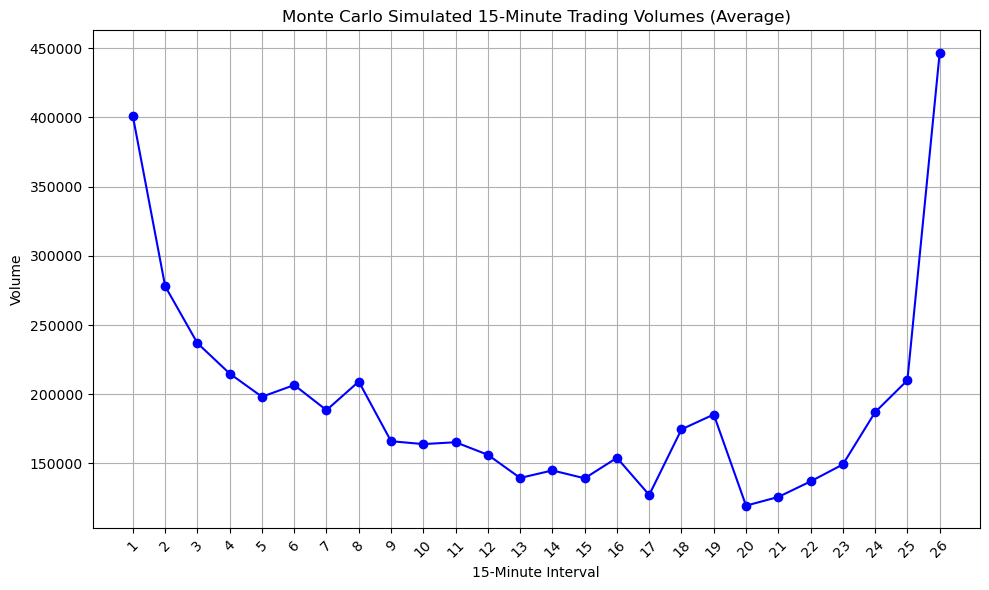

In [9]:
import numpy as np

num_simulations = 1000  # Number of Monte Carlo simulations

simulated_volumes = np.zeros((num_simulations, 26))

for i in range(num_simulations):
    expected_daily_volume = np.random.choice(volume_matrix.sum(axis=1))

    bootstrapped_proportions = volume_proportion_matrix.sample(n=1, replace=True).values.flatten()

    simulated_volumes[i] = bootstrapped_proportions * expected_daily_volume

mean_simulated_volumes = simulated_volumes.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 27), mean_simulated_volumes, marker='o', linestyle='-', color='b')
plt.title("Monte Carlo Simulated 15-Minute Trading Volumes (Average)")
plt.xlabel("15-Minute Interval")
plt.ylabel("Volume")
plt.xticks(range(1, 27), [f"{intvl+1}" for intvl in range(26)], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


### NOTE: The following code applies when a large stakeholder does liquidation. Do not run except this condition

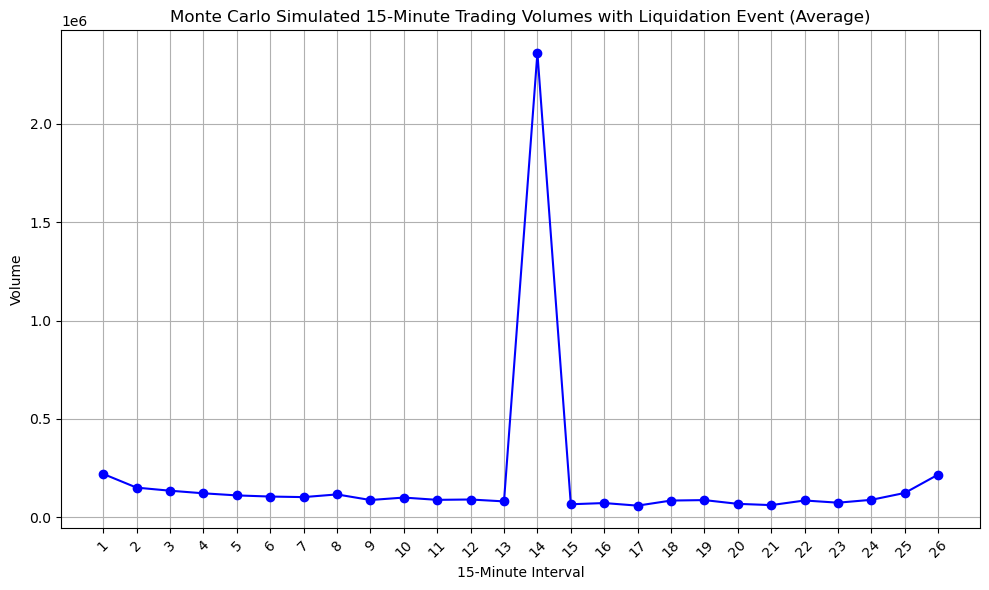

In [84]:
num_simulations = 1000  # Number of Monte Carlo simulations
p = 0.10  # Reduction in volume after the liquidation event (10%)

top_2_percent_value = np.percentile(volume_matrix.values.flatten(), 98)
top_2_percent_volumes = volume_matrix.values.flatten()[volume_matrix.values.flatten() >= top_2_percent_value]

simulated_volumes = np.zeros((num_simulations, 26))

for i in range(num_simulations):
    expected_daily_volume = np.random.choice(volume_matrix.sum(axis=1))
    
    bootstrapped_proportions = volume_proportion_matrix.sample(n=1, replace=True).values.flatten()
    
    liquidation_time = 13
    liquidation_volume = np.random.choice(top_2_percent_volumes)
    
    remaining_daily_volume = expected_daily_volume - liquidation_volume
    
    simulated_daily_volumes = bootstrapped_proportions * remaining_daily_volume
    simulated_daily_volumes[liquidation_time] += liquidation_volume

    if liquidation_time < 25:
        simulated_daily_volumes[liquidation_time+1:] *= (1 - p)
    
    simulated_volumes[i] = simulated_daily_volumes

mean_simulated_volumes = simulated_volumes.mean(axis=0)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 27), mean_simulated_volumes, marker='o', linestyle='-', color='b')
plt.title("Monte Carlo Simulated 15-Minute Trading Volumes with Liquidation Event (Average)")
plt.xlabel("15-Minute Interval")
plt.ylabel("Volume")
plt.xticks(range(1, 27), [f"{intvl+1}" for intvl in range(26)], rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## 2. Volume model with price simulated under different processes
## Note: The coefficients under the following three models should be estimated by Time-series regression from past data. Right now set by hand

### 2.1 Under Geometric Brownian Motion Process with stochastic volatility scaled by volume model

#### $$ P_{t} = P_{0}⋅e^{(\mu - \sigma^2)t + \sigma W_{t}} $$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P0 = 100  # Initial price
mu = 0.02  # Drift
sigma_0 = 0.0285 # From Market Impact Model
T = 390 

# Distribute volumes over minutes
minute_volumes = np.repeat(mean_simulated_volumes / 15, 15)
mean_volume = np.mean(mean_simulated_volumes) / 15  # Mean per-minute volume
volatility = sigma_0 * np.sqrt(minute_volumes / mean_volume)

# Simulate GBM with stochastic volatility
np.random.seed(42)
Z = np.random.normal(0, 1, T)
prices = [P0]
for t in range(1, T):
    dt = 1 / 390 
    sigma_t = volatility[t]
    P_t = prices[-1] * np.exp((mu - 0.5 * sigma_t**2) * dt + sigma_t * np.sqrt(dt) * Z[t])
    prices.append(P_t)

trade_book = pd.DataFrame({
    'Minute': np.arange(1, T + 1),
    'Price': prices,
    'Volume': minute_volumes
})

plt.figure(figsize=(10, 5))
plt.plot(trade_book['Minute'], trade_book['Price'], label='Simulated Prices')
plt.title('Minute-by-Minute Simulated Prices')
plt.xlabel('Minute')
plt.ylabel('Price')
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(trade_book['Minute'], trade_book['Volume'], label='Per-Minute Volumes', color='orange')
plt.title('Minute-by-Minute Distributed Volumes')
plt.xlabel('Minute')
plt.ylabel('Volume')
plt.legend()
plt.show()


NameError: name 'mean_simulated_volumes' is not defined

### 2.2 Under Mean-Reversion Process (Ornstein-Uhlenbeck Process)

#### $$ dP_{t} =  \theta (\mu - P_{t})dt+ \sigma W_{t} $$

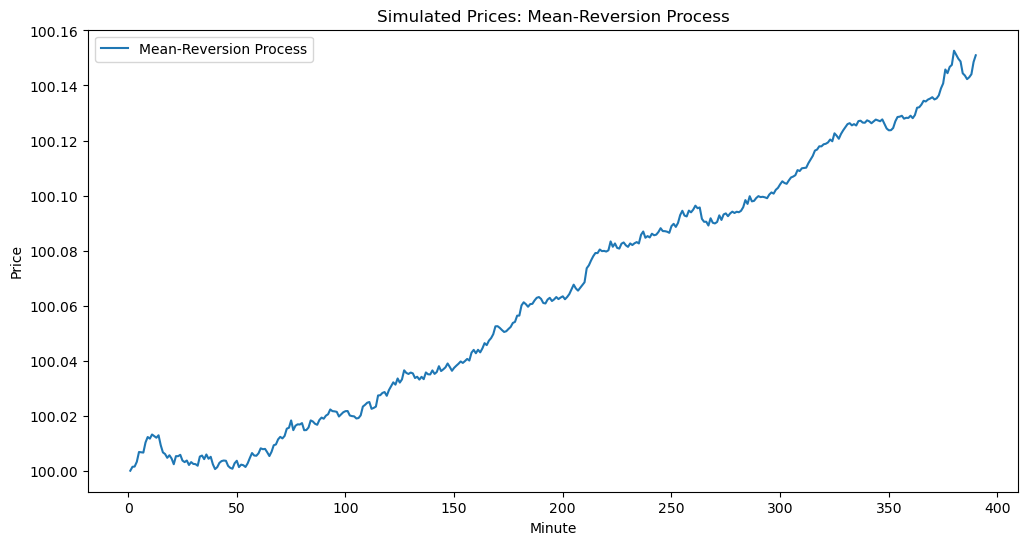

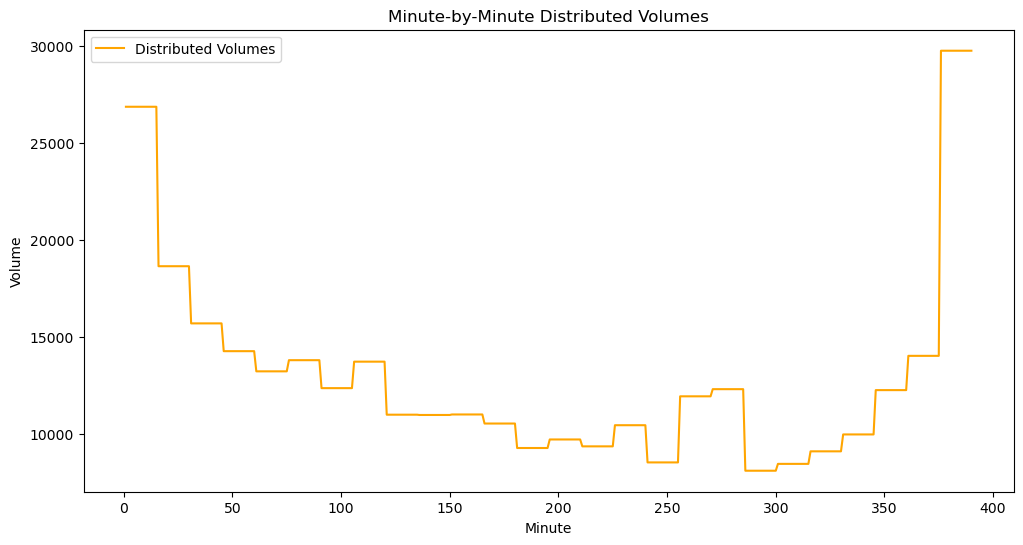

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T = 390  
P0 = 100  # Initial price
mu = 101.5  # Long-term mean price
theta = 0.1  
sigma = 0.0285  
dt = 1 / 390 
np.random.seed(42)

minute_volumes = np.repeat(mean_simulated_volumes / 15, 15)
mean_volume = np.mean(mean_simulated_volumes) / 15
volatility = sigma * np.sqrt(minute_volumes / mean_volume)

# the Ornstein-Uhlenbeck process
prices_ou = [P0] 
for t in range(1, T):
    dW = np.random.normal(0, 1) * np.sqrt(dt) 
    dP = theta * (mu - prices_ou[-1]) * dt + volatility[t] * dW
    prices_ou.append(prices_ou[-1] + dP)

trade_book_ou = pd.DataFrame({
    'Minute': np.arange(1, T + 1),
    'Price': prices_ou,
    'Volume': minute_volumes
})

plt.figure(figsize=(12, 6))
plt.plot(trade_book_ou['Minute'], trade_book_ou['Price'], label='Mean-Reversion Process')
plt.title('Simulated Prices: Mean-Reversion Process')
plt.xlabel('Minute')
plt.ylabel('Price')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(trade_book_ou['Minute'], trade_book_ou['Volume'], label='Distributed Volumes', color='orange')
plt.title('Minute-by-Minute Distributed Volumes')
plt.xlabel('Minute')
plt.ylabel('Volume')
plt.legend()
plt.show()


### 2.3 Under Jump Diffusion Process (Under large liquidation only)

#### $$ P_{t} = P_{0}⋅e^{(\mu - \sigma^2)t + \sigma W_{t}} + J_{t}$$

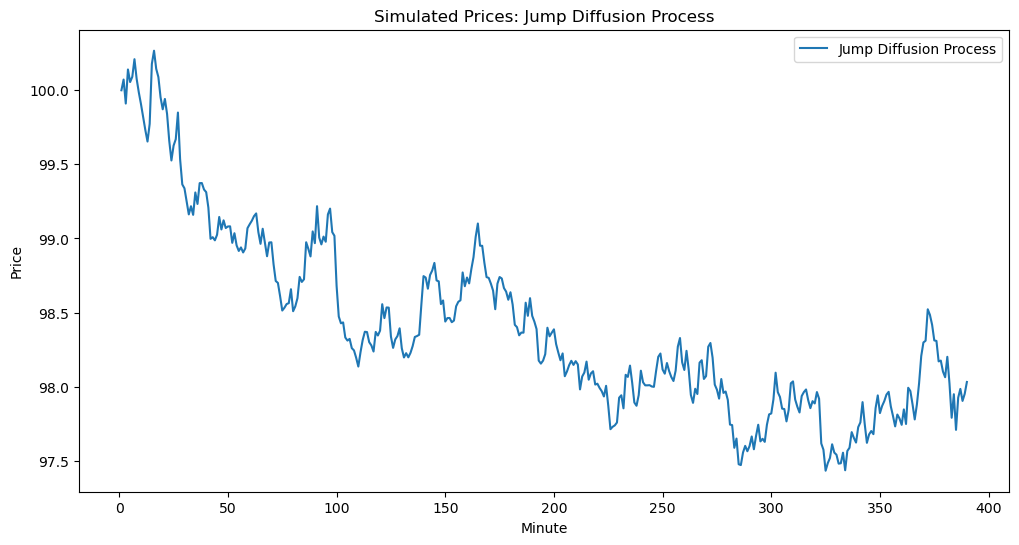

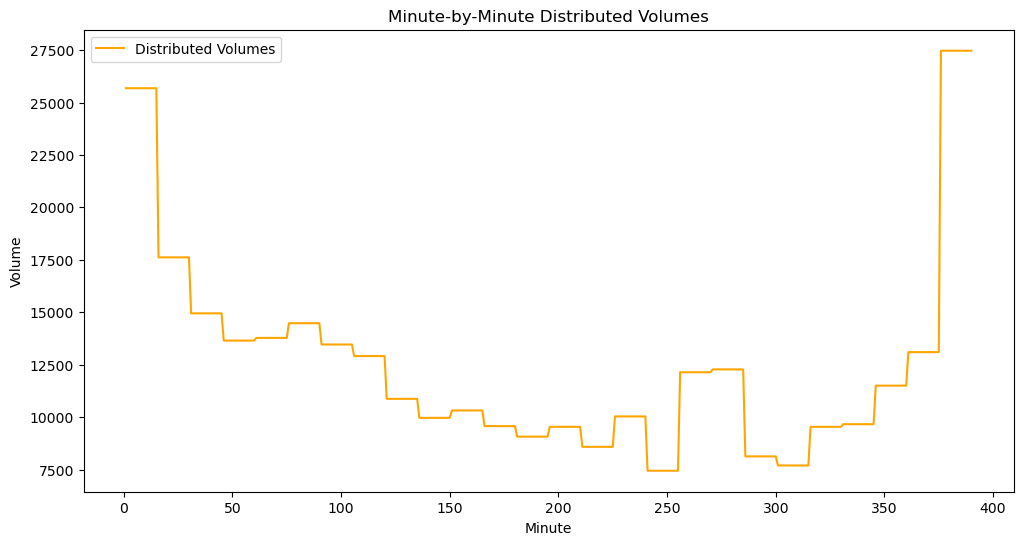

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T = 390 
P0 = 100  # Initial price
mu = 0.0002  # Drift
sigma = 0.02  # Volatility
lambda_jump = 0.02  # Jump intensity (average number of jumps per unit time)
k_mean = 0.05  # Mean jump size (percentage)
dt = 1 / 390  
np.random.seed(42)

minute_volumes = np.repeat(mean_simulated_volumes / 15, 15)
mean_volume = np.mean(mean_simulated_volumes) / 15  # Mean per-minute volume

volatility = sigma * np.sqrt(minute_volumes / mean_volume)

prices_jump = [P0]
for t in range(1, T):
    Z = np.random.normal(0, 1)
    jump = np.random.choice(
        [np.log(1 + np.random.normal(k_mean, k_mean / 2)), 0], 
        p=[lambda_jump * dt, 1 - lambda_jump * dt]
    )
    dP = (mu - 0.5 * volatility[t]**2) * dt + volatility[t] * np.sqrt(dt) * Z + jump
    prices_jump.append(prices_jump[-1] * np.exp(dP))

trade_book_jump = pd.DataFrame({
    'Minute': np.arange(1, T + 1),
    'Price': prices_jump,
    'Volume': minute_volumes
})

plt.figure(figsize=(12, 6))
plt.plot(trade_book_jump['Minute'], trade_book_jump['Price'], label='Jump Diffusion Process')
plt.title('Simulated Prices: Jump Diffusion Process')
plt.xlabel('Minute')
plt.ylabel('Price')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(trade_book_jump['Minute'], trade_book_jump['Volume'], label='Distributed Volumes', color='orange')
plt.title('Minute-by-Minute Distributed Volumes')
plt.xlabel('Minute')
plt.ylabel('Volume')
plt.legend()
plt.show()

## 3. Insert into market impact and sample trade clasue

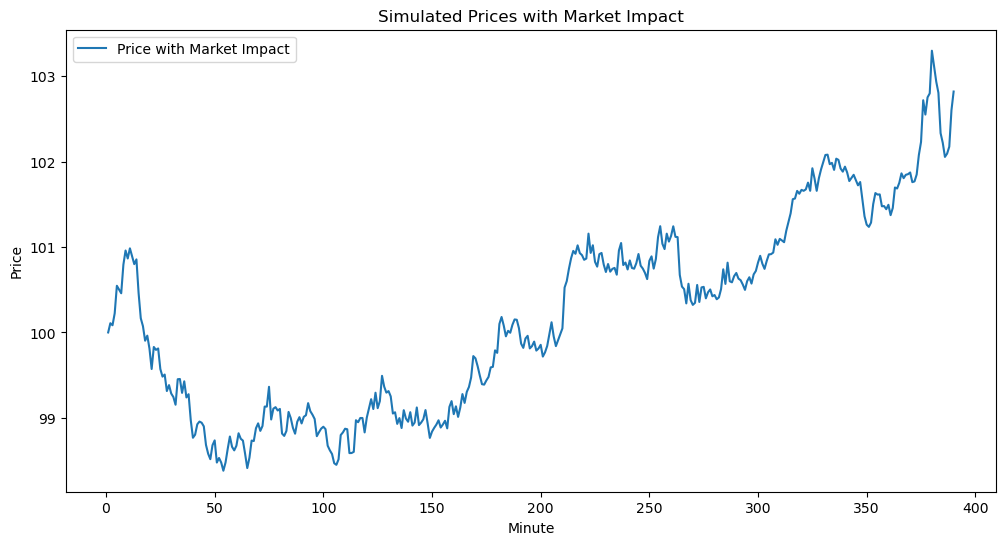

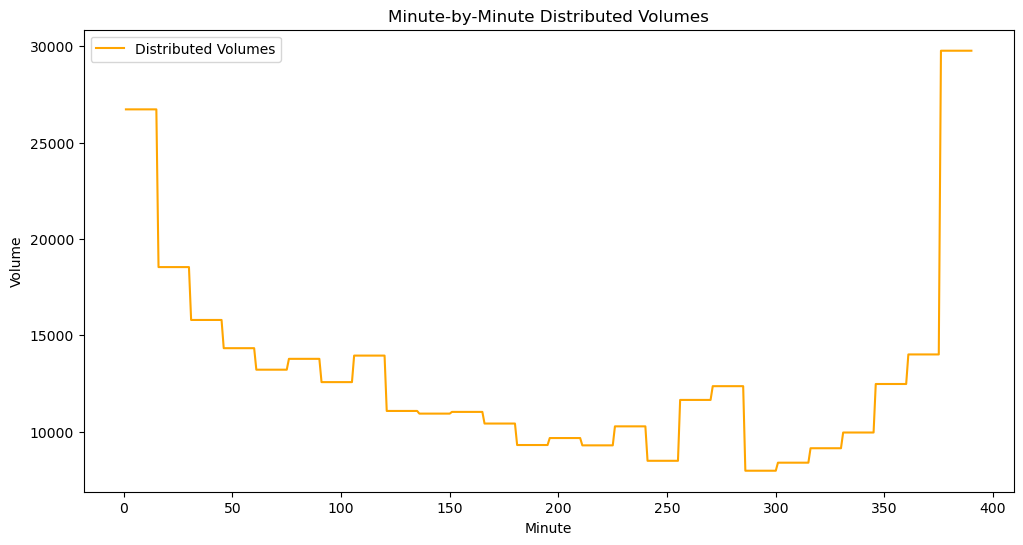

,Minute,Price,Volume
100,101,98.867330,12566.027050
200,201,99.717397,9662.059291


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

T = 390  # Number of minutes in a trading day
P0 = 100  # Initial price
mu = 0.02  # Drift
sigma = 0.0285  # Volatility
dt = 1 / 390 
np.random.seed(42)

eta_temp = 0.1  
eta_perm = 0.05 
beta = 0.6
execution_clauses = {100: 500, 200: 1000} 

minute_volumes = np.repeat(mean_simulated_volumes / 15, 15)
mean_volume = np.mean(mean_simulated_volumes) / 15 

prices = [P0]
volatility = sigma * np.sqrt(minute_volumes / mean_volume)
trade_book = pd.DataFrame({'Minute': np.arange(1, T + 1), 'Price': np.nan, 'Volume': minute_volumes})
trade_book.loc[0, 'Price'] = P0

for t in range(1, T):
    Z = np.random.normal(0, 1)  # Brownian motion increment
    dP = (mu - 0.5 * volatility[t]**2) * dt + volatility[t] * np.sqrt(dt) * Z
    
    # Check if trade is executed at this time
    if t in execution_clauses:
        n = execution_clauses[t] 
        V = trade_book.loc[t, 'Volume'] 
        temp_impact = eta_temp * (n / V) ** beta
        perm_impact = eta_perm * (n / V)
        
        prices[-1] += temp_impact + perm_impact

    # Resume stochastic process
    prices.append(prices[-1] * np.exp(dP))

trade_book['Price'] = prices

plt.figure(figsize=(12, 6))
plt.plot(trade_book['Minute'], trade_book['Price'], label='Price with Market Impact')
plt.title('Simulated Prices with Market Impact')
plt.xlabel('Minute')
plt.ylabel('Price')
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(trade_book['Minute'], trade_book['Volume'], label='Distributed Volumes', color='orange')
plt.title('Minute-by-Minute Distributed Volumes')
plt.xlabel('Minute')
plt.ylabel('Volume')
plt.legend()
plt.show()

trade_book.loc[list(execution_clauses.keys())]
